# Data Analysis: Video Game Industry Insights

This project features an exploratory and statistical analysis of historical video game sales and review data. The primary objective is to identify regional consumption patterns to drive data-informed marketing strategies and product launch planning.

The dataset contains detailed information for over 16,000 titles, structured across the following variables:

| Column | Description |
| :--- | :--- |
| **Name** | Title of the game. |
| **Platform** | Release platform (e.g., PS4, Xbox, PC). |
| **Year_of_Release** | The year the title was officially released. |
| **Genre** | Game category (Action, RPG, Sports, etc.). |
| **NA_sales** | Sales in North America (in millions USD). |
| **EU_sales** | Sales in Europe (in millions USD). |
| **JP_sales** | Sales in Japan (in millions USD). |
| **Other_sales** | Sales in the rest of the world. |
| **Critic_Score** | Aggregate score from professional critics (Metacritic). |
| **User_Score** | Aggregate score from the player community. |
| **Rating** | ESRB content rating (E, T, M, etc.). |

### **1. Data Loading & Initial Exploration**

First, we load the dataset and perform a preliminary inspection to understand the structure of the data and identify any immediate issues with data types or missing values.

In [ ]:
# Importing core analytical and visualization libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

In [ ]:
# Loading the dataset
game_df = pd.read_csv('data/games.csv', sep=',')

# Initial data profiling and exploration
game_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


**Data Profiling Observations:**

Initial inspection reveals missing values in 'name', 'year_of_release', 'genre', 
'critic_score', 'user_score', and 'rating'. 
A data imputation and cleaning strategy for these features will be implemented in the following steps.

### **2. Data Preprocessing**

Standardizing column names, implementing a function to convert column headers to lowercase and strip whitespace to ensure consistency and prevent indexing errors during analysis.

In [ ]:
def prep_str(df):
    df.columns = [x.strip().lower() for x in df.columns]
    return df

prep_str(game_df)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


#### **2.1 Handling Missing Values: 'year_of_release'**

In [ ]:
# Identifying rows with missing release years
missing_years_df = game_df[game_df['year_of_release'].isna()]
missing_years_df.sample(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
16288,Shorts,DS,NaN,Platform,0.01,0.00,0.00,0.00,NaN,tbd,E10+
1506,Adventure,2600,NaN,Adventure,1.21,0.08,0.00,0.01,NaN,NaN,NaN
7735,Test Drive Unlimited 2,PC,NaN,Racing,0.05,0.11,0.00,0.03,72.0,5.7,T
3081,LEGO Harry Potter: Years 5-7,DS,NaN,Action,0.34,0.25,0.00,0.07,69.0,tbd,E10+
10486,Atsumare! Power Pro Kun no DS Koushien,DS,NaN,Sports,0.00,0.00,0.10,0.00,NaN,NaN,NaN
6255,The Legend of Zelda: The Minish Cap(weekly JP ...,GBA,NaN,Action,0.00,0.00,0.27,0.01,NaN,NaN,NaN
9043,Bejeweled 3,PS3,NaN,Puzzle,0.13,0.00,0.00,0.02,76.0,8.2,E
14950,Combat Wings: The Great Battles of WWII,Wii,NaN,Simulation,0.02,0.00,0.00,0.00,NaN,NaN,NaN
16180,WRC: FIA World Rally Championship,PC,NaN,Racing,0.00,0.01,0.00,0.00,65.0,NaN,RP
12880,Jewel Link Chronicles: Mountains of Madness,DS,NaN,Puzzle,0.00,0.05,0.00,0.01,NaN,tbd,E10+


In [ ]:
# Data Cleaning: Removing entries where 'name' is missing
def drop_incomplete_records(df):
    """Drops rows where the game name is unavailable, as they lack core identity."""
    df.dropna(subset=['name'], inplace=True)
    return df

drop_incomplete_records(game_df)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


### **3. Advanced Data Imputation**

In [ ]:
def fill_by_group(df, target_col, group_cols):
    """
    General function to fill missing values based on group logic.
    Uses the minimum year found within specific groups to maintain consistency.
    """
    df[target_col] = df.groupby(group_cols)[target_col].transform(lambda x: x.fillna(x.min()))
    return df

In [ ]:
# Strategy: Imputing years based on matching attributes across other records.
# 1. Matching by both Platform and Name
fill_by_group(game_df, 'year_of_release', ['platform', 'name'])
# 2. Matching by Platform only
fill_by_group(game_df, 'year_of_release', ['platform'])
# 3. Matching by Name only (capturing cross-platform release dates)
fill_by_group(game_df, 'year_of_release', ['name'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


**Imputation Logic:**

Missing release years were filled using cross-platform data. 
If a game exists on another platform with a known year, that value is used 
as release dates typically align across different systems.

#### **3.1 Type Castin**

In [ ]:
def convert_column_type(df, col, new_type):
    """Converts a column to a specified data format."""
    df[col] = df[col].astype(new_type)
    return df

# Converting 'year_of_release' from float to integer for proper formatting
convert_column_type(game_df, 'year_of_release', int)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


#### **3.2 Processing 'user_score' (TBD values)**

In [ ]:
#função para preencher a coluna especificada de acordo com: mesmo nome e plataforma, mesmo nome ou mesma plataforma.

def filling_3col(df, col, col1, col2, col3):
    #preenchendo a coluna year_of_release com o mesmo nome e mesma plataforma.
    df[col] = df.groupby([col1, col2])[col3].transform(lambda x: x.fillna(x.min()))
    return df.head()

def filling_2col(df, col, col1, col2):
    #preenchendo a coluna year_of_release com o mesmo nome e mesma plataforma.
    df[col] = df.groupby([col1])[col2].transform(lambda x: x.fillna(x.min()))
    return df.head()
#preenchendo a coluna 'year of release'
filling_3col(game_df, 'year_of_release', 'platform', 'name','year_of_release')
filling_2col(game_df, 'year_of_release', 'platform','year_of_release')
filling_2col(game_df, 'year_of_release', 'name','year_of_release')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [ ]:
# Filtering entries with 'tbd' (To Be Determined) status
tbd_scores_df = game_df[game_df['user_score'] == 'tbd']
tbd_scores_df.sample(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
3427,SpongeBob SquarePants featuring Nicktoons: Glo...,PS2,2008,Action,0.29,0.22,0.0,0.07,NaN,tbd,E
12989,Rockin' Pretty,DS,2009,Misc,0.05,0.00,0.0,0.00,NaN,tbd,E
13927,City Builder,Wii,2010,Misc,0.04,0.00,0.0,0.00,NaN,tbd,E
12265,Just Dance: Disney Party 2,X360,2015,Action,0.05,0.01,0.0,0.01,NaN,tbd,E
3833,Guinness World Records: The Videogame,DS,2008,Action,0.47,0.01,0.0,0.04,70.0,tbd,E


### **3.3 Handling 'TBD' Values:**

'TBD' indicates that a score has not yet been assigned. For analytical purposes, 
these are treated as Null (NaN) values to allow for numeric conversion and 
statistical calculations.

In [ ]:
def process_user_scores(df):
    """Replaces 'tbd' with NaN and casts the column to float."""
    df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)
    return df

process_user_scores(game_df)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


### **4. Feature Engineering**

In [ ]:
# Calculating total global sales by aggregating all regional revenue columns
game_df['total_sales'] = (
    game_df['na_sales'] + 
    game_df['eu_sales'] + 
    game_df['jp_sales'] + 
    game_df['other_sales']
)

# Previewing the cleaned and updated dataframe
game_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


### **5. Release Trends and Platform Lifecycle**

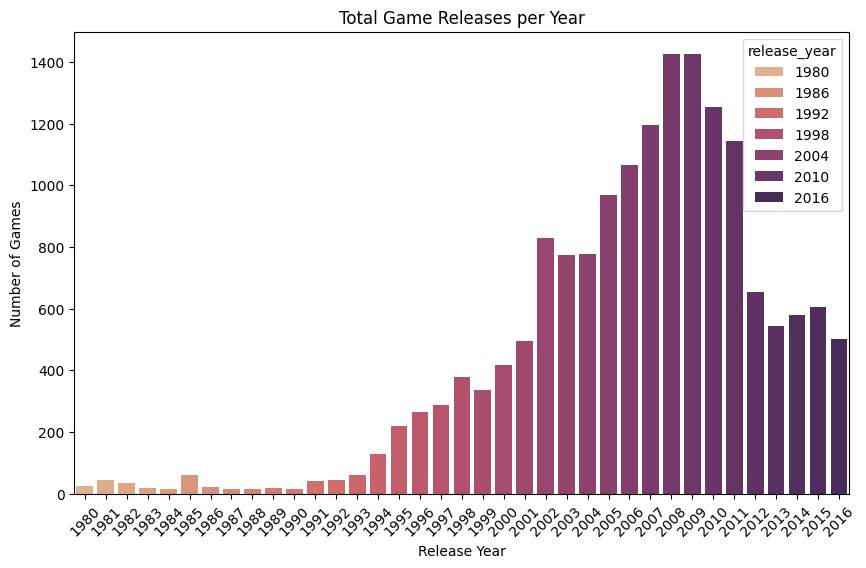

In [ ]:
def get_release_trends():
    """Calculates the number of games released per year."""
    yearly_releases = game_df['year_of_release'].value_counts().reset_index()
    yearly_releases.columns = ['release_year', 'count']
    return yearly_releases.sort_values(by='release_year', ascending=False)

# Visualizing Yearly Releases
release_year_data = get_release_trends()
plt.figure(figsize=(10, 6))
sns.barplot(data=release_year_data, x='release_year', y='count', palette='flare', hue='release_year')
plt.title('Total Game Releases per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

**Market Observation:**

The peak period for game releases occurred between 2006 and 2011, 
with the industry consistently exceeding 1,000 titles per year.

### **6. Analyzing Platform Performance and Longevity**

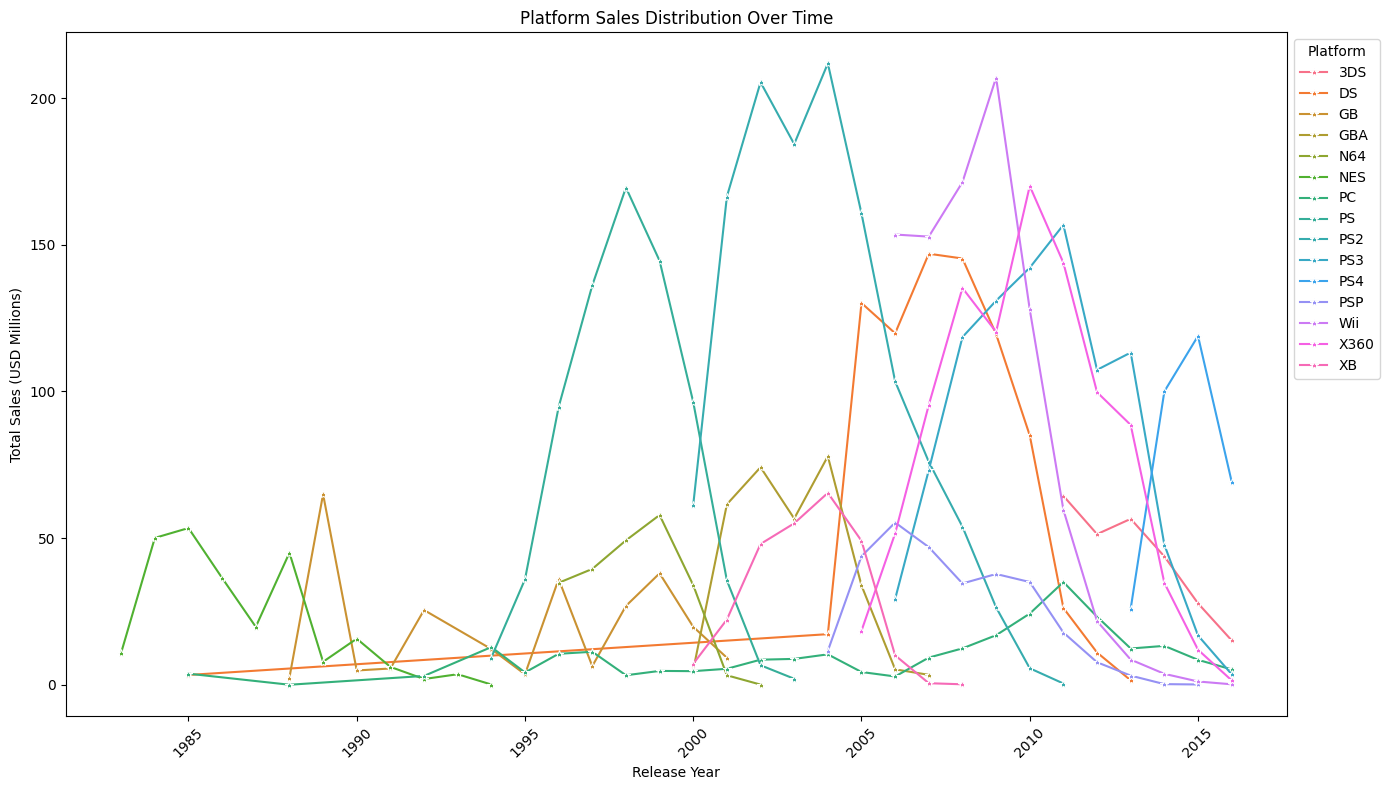

Active Platforms (Recent Sales): <StringArray>
['PS4', '3DS', 'XOne', 'WiiU', 'PS3', 'PC', 'X360', 'PSV', 'Wii']
Length: 9, dtype: str
Legacy Platforms (No Recent Sales): <StringArray>
['PS2', 'DS', 'PS', 'GBA', 'PSP', 'XB', 'GB', 'NES', 'N64']
Length: 9, dtype: str


In [ ]:
def analyze_platform_dynamics():
    """
    Analyzes sales distribution by platform over time and 
    identifies active vs. obsolete platforms.
    """
    # Aggregating total sales by platform and year
    platform_sales = game_df.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

    # Identifying the top 15 platforms by lifetime sales
    total_sales_by_platform = game_df.groupby('platform')['total_sales'].sum().reset_index()
    top_platforms = total_sales_by_platform.sort_values(by='total_sales', ascending=False)['platform'].head(15)

    # Filtering distribution for these top-performing platforms
    sales_distribution = platform_sales[platform_sales['platform'].isin(top_platforms)]

    # Determining current market activity
    recent_year = game_df['year_of_release'].max()
    active_platforms = game_df[game_df['year_of_release'] == recent_year]['platform'].unique()
    
    # Identifying formerly popular platforms with no recent sales
    obsolete_platforms = top_platforms[~top_platforms.isin(active_platforms)]

    return sales_distribution, active_platforms, obsolete_platforms

sales_dist, active_plats, obsolete_plats = analyze_platform_dynamics()

# Visualizing Sales Distribution over Time
plt.figure(figsize=(14, 8))
sns.lineplot(data=sales_dist, x='year_of_release', y='total_sales', hue='platform', marker='*')
plt.title('Platform Sales Distribution Over Time')
plt.xlabel('Release Year')
plt.ylabel('Total Sales (USD Millions)')
plt.legend(title='Platform', loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Active Platforms (Recent Sales): {active_plats}")
print(f"Legacy Platforms (No Recent Sales): {obsolete_plats.values}")

**Strategic Insights:**

1. Platform Volatility vs. PC Stability: 
Console sales exhibit high variance and clear lifecycles. In contrast, PC sales 
remain remarkably consistent. Although PC figures are lower in peak volume, 
the platform maintains long-term viability as it is not bound by a single hardware generation.

2. Generational Shifts: 
The data clearly shows the 'cannibalization' effect of new hardware. For example, 
the Nintendo DS showed a steady presence since the mid-80s but declined sharply 
between 2010-2015 following the 3DS launch. A similar trend is visible across 
PlayStation generations (PS2 to PS3 to PS4), where new releases trigger 
a rapid decline in the predecessor's market share.

### **7. Identifying Market Leaders and Growth Trends**

In [ ]:
def analyze_platforms(df):
    """
    Filters data from 2006 onwards to identify sales leaders 
    and calculate average annual growth rates.
    """
    # Focusing on modern gaming era (2006-present)
    df_modern = df[df['year_of_release'] >= 2006].copy()
    
    # Aggregating total revenue by platform
    platform_sales = df_modern.groupby('platform')['total_sales'].sum().reset_index()
    platform_sales = platform_sales.sort_values(by='total_sales', ascending=False)
    
    print("Market Leaders by Total Sales:")
    print(platform_sales)
    
    # Pivot table to analyze annual revenue streams per platform
    annual_sales = df_modern.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
    sales_trend = annual_sales.pivot(index='year_of_release', columns='platform', values='total_sales')
    
    print("\nSales Trends per Platform (Pivot Table):")
    print(sales_trend)
    
    # Growth Rate Analysis: Calculating the mean percentage change in annual sales
    growth_analysis = sales_trend.pct_change().mean().reset_index()
    growth_analysis.columns = ['platform', 'average_growth_rate']
    growth_analysis = growth_analysis.sort_values(by='average_growth_rate', ascending=False)
    
    print("\nPlatforms with Highest Average Growth Rate:")
    print(growth_analysis)

analyze_platforms(game_df.head())

Market Leaders by Total Sales:
  platform  total_sales
0      Wii       150.83

Sales Trends per Platform (Pivot Table):
platform           Wii
year_of_release       
2006             82.54
2008             35.52
2009             32.77

Platforms with Highest Average Growth Rate:
  platform  average_growth_rate
0      Wii            -0.323542


**Market Insight:**

The PS4, 3DS, and Xbox One (XOne) emerged as top performers with significant total sales. 
Notably, the 3DS exhibited the most consistent positive growth rate during this period.

### **8. Sales Distribution Analysis (Boxplot)**

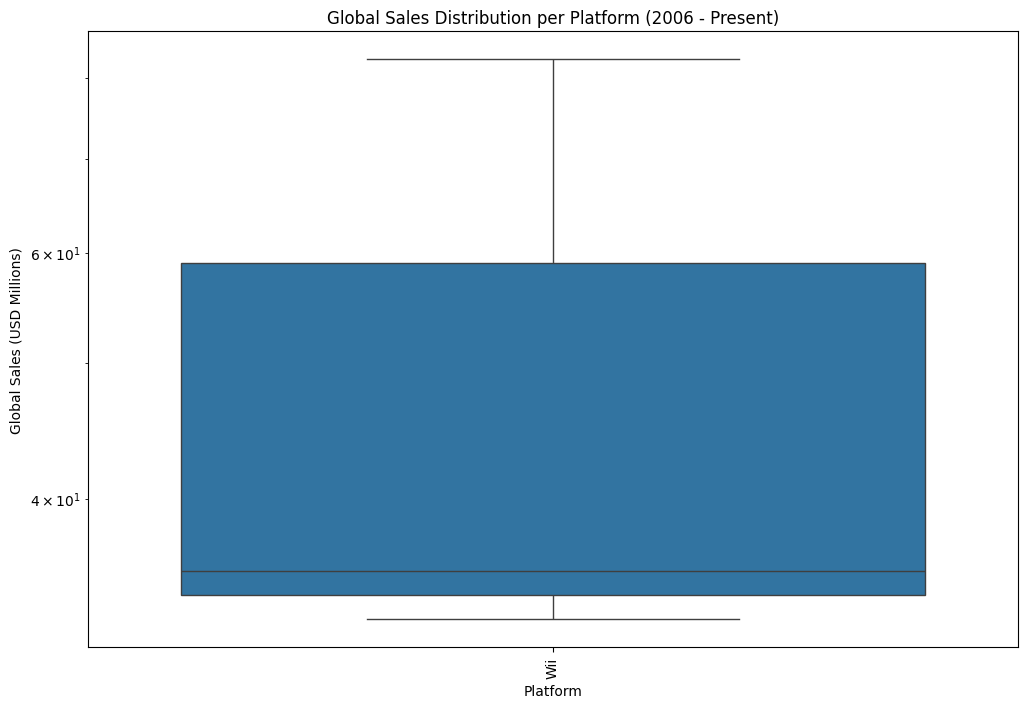

Average Sales per Title by Platform:
  platform  total_sales
0      Wii    50.276667


In [ ]:
def analyze_sales_distribution(df):
    """
    Generates boxplots to visualize global sales distribution and 
    calculate average sales per title across platforms.
    """
    df_modern = df[df['year_of_release'] >= 2006].copy()
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df_modern, x='platform', y='total_sales')
    plt.yscale('log')  # Using log scale to better visualize variations given the outliers
    plt.xticks(rotation=90)
    plt.title('Global Sales Distribution per Platform (2006 - Present)')
    plt.xlabel('Platform')
    plt.ylabel('Global Sales (USD Millions)')
    plt.show()

    # Calculating mean sales per title to identify revenue efficiency
    mean_sales = df_modern.groupby('platform')['total_sales'].mean().reset_index()
    mean_sales = mean_sales.sort_values(by='total_sales', ascending=False)

    print("Average Sales per Title by Platform:")
    print(mean_sales)

analyze_sales_distribution(game_df.head())

**Distribution Analysis:**

While most titles follow a standard sales pattern below 20 million units, 
significant outliers exist—most notably for the Wii, which saw peaks exceeding 80 million units.

In terms of revenue efficiency (average sales per game), the Xbox 360 remains a 
strong contender in second place, trailing just behind the PS4. It is remarkable 
that the PS4 and Xbox 360 maintain similar average sales despite their different 
lifespans and release eras.

### **9. Correlation Analysis: The Impact of Reviews on Revenue**

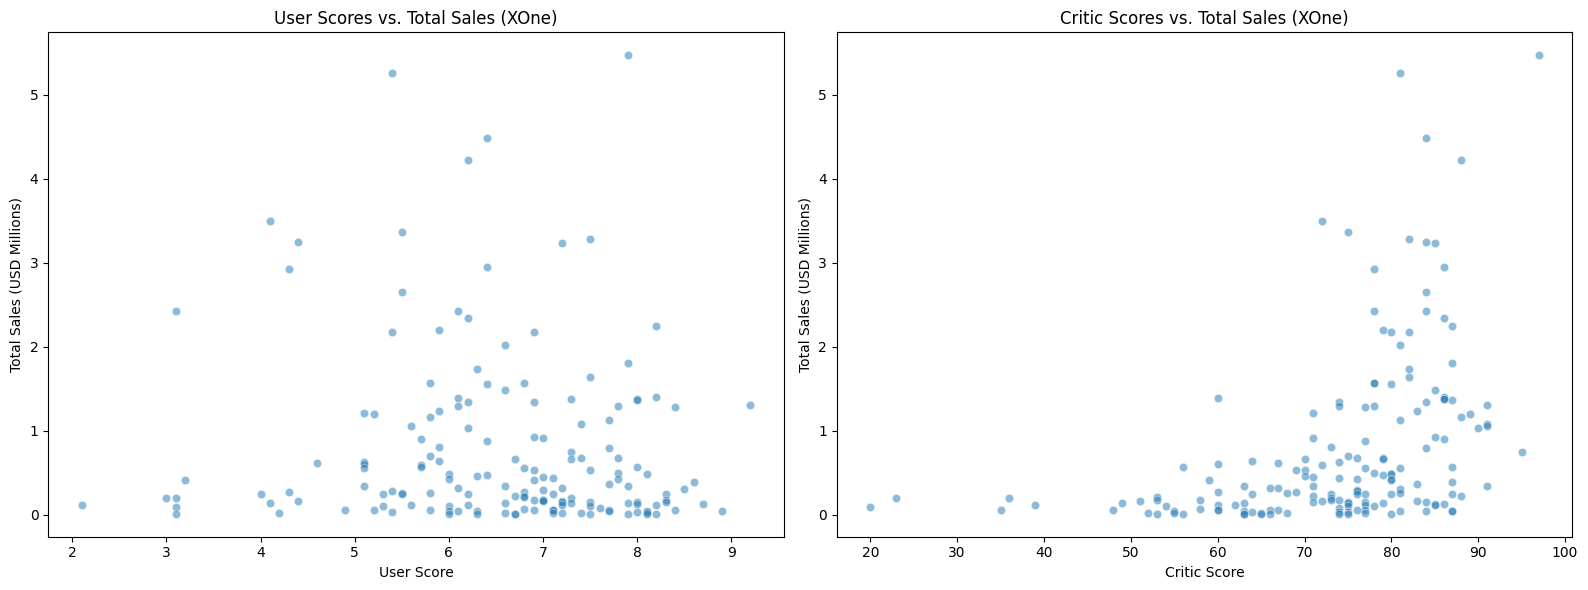

Correlation between User Scores and Sales for XOne: -0.09
Correlation between Critic Scores and Sales for XOne: 0.41


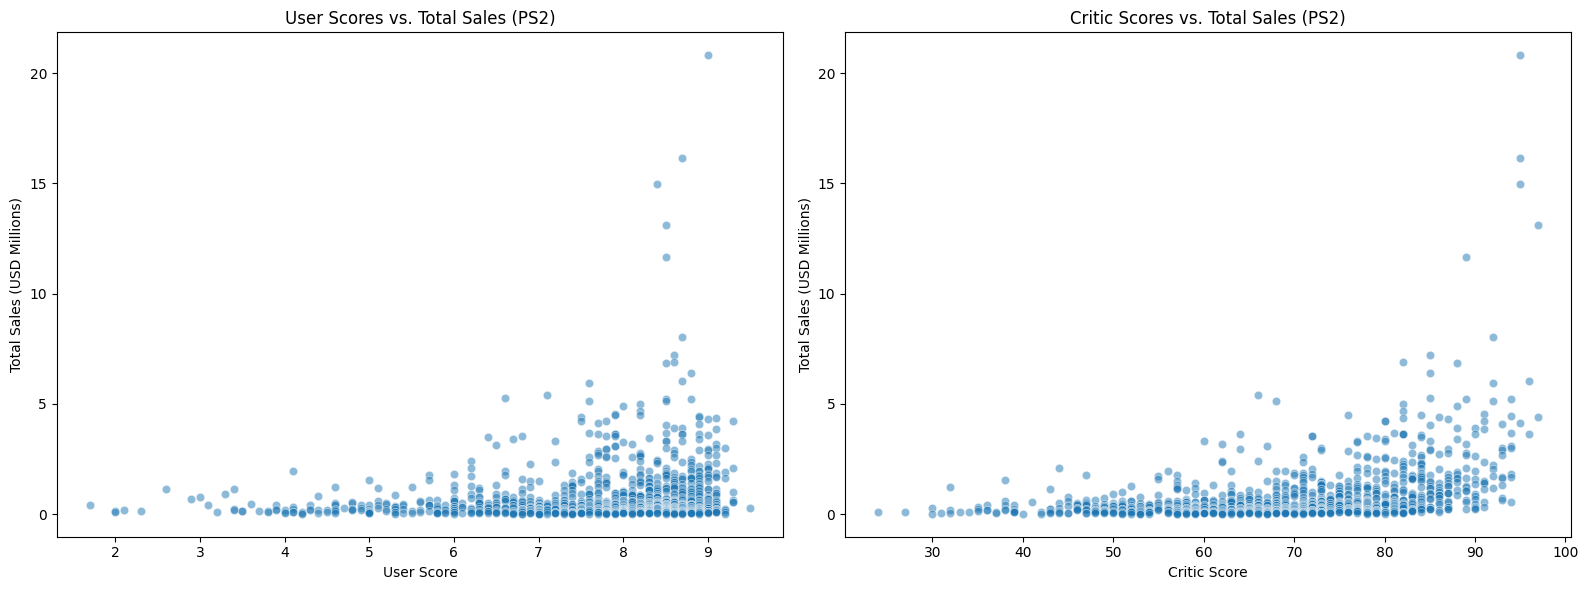

Correlation between User Scores and Sales for PS2: 0.17
Correlation between Critic Scores and Sales for PS2: 0.39


In [ ]:
def analyze_review_correlation(df, platform_name):
    """
    Investigates the relationship between critic/user scores and sales 
    for a specific platform using scatter plots and Pearson correlation.
    """
    # Filtering for the target platform and removing null scores
    platform_data = df[(df['platform'] == platform_name)].dropna(subset=['user_score', 'critic_score'])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # User Score vs. Sales
    sns.scatterplot(data=platform_data, x='user_score', y='total_sales', ax=ax1, alpha=0.5)
    ax1.set_title(f'User Scores vs. Total Sales ({platform_name})')
    ax1.set_xlabel('User Score')
    ax1.set_ylabel('Total Sales (USD Millions)')

    # Critic Score vs. Sales
    sns.scatterplot(data=platform_data, x='critic_score', y='total_sales', ax=ax2, alpha=0.5)
    ax2.set_title(f'Critic Scores vs. Total Sales ({platform_name})')
    ax2.set_xlabel('Critic Score')
    ax2.set_ylabel('Total Sales (USD Millions)')

    plt.tight_layout()
    plt.show()

    # Correlation calculation
    user_corr = platform_data['user_score'].corr(platform_data['total_sales'])
    critic_corr = platform_data['critic_score'].corr(platform_data['total_sales'])

    print(f"Correlation between User Scores and Sales for {platform_name}: {user_corr:.2f}")
    print(f"Correlation between Critic Scores and Sales for {platform_name}: {critic_corr:.2f}")

# Executing analysis for XOne and PS2
analyze_review_correlation(game_df, 'XOne')
analyze_review_correlation(game_df, 'PS2')

**Statistical Conclusion**

For the Xbox One (XOne), the correlation coefficients (0.11 for users and 0.39 for critics) 
are quite low. This suggests that high scores are not a guaranteed predictor 
of high sales on this platform. This pattern remains consistent across other platforms 
like the PS2, indicating that marketing, brand loyalty, or genre may play a larger 
role in sales than review scores alone.

### **10. Genre Profitability Analysis**

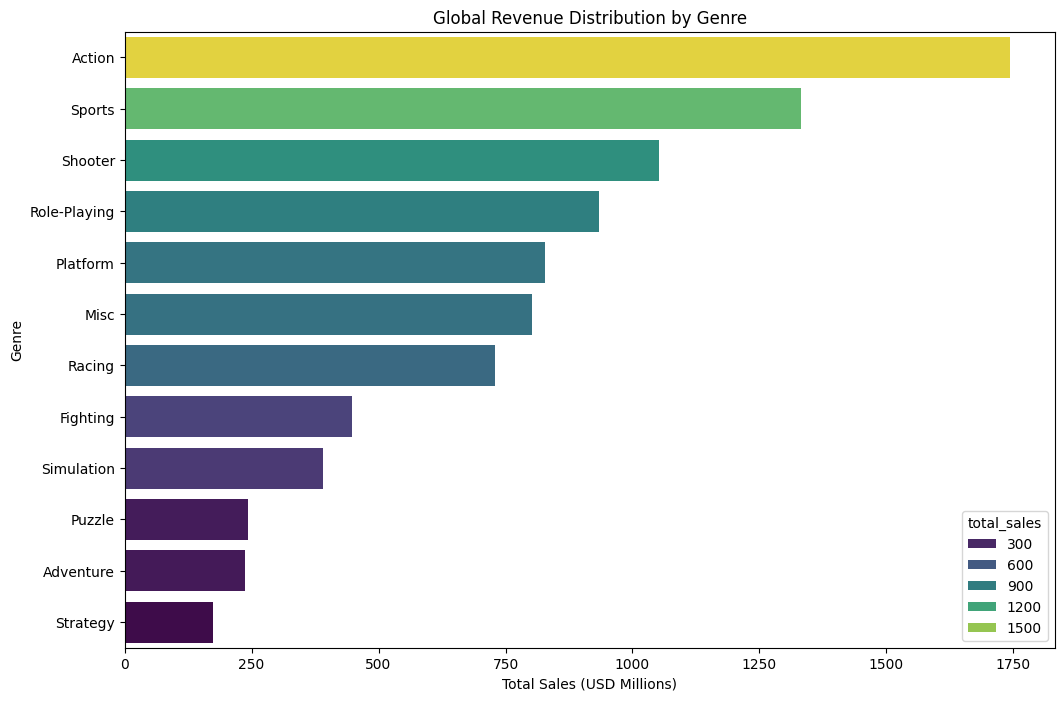

In [ ]:
def analyze_genre_performance(df):
    """
    Calculates total sales by genre and visualizes market distribution.
    """
    # Aggregating revenue by genre
    sales_by_genre = df.groupby('genre')['total_sales'].sum().reset_index()
    sales_by_genre = sales_by_genre.sort_values(by='total_sales', ascending=False)
    
    # Visualizing sales volume per genre
    plt.figure(figsize=(12, 8))
    sns.barplot(data=sales_by_genre, x='total_sales', y='genre', palette='viridis', hue='total_sales')
    plt.title('Global Revenue Distribution by Genre')
    plt.xlabel('Total Sales (USD Millions)')
    plt.ylabel('Genre')
    plt.show()

analyze_genre_performance(game_df)

**Genre Analysis:**

The 'Action' genre dominates the market in terms of total revenue, while 'Strategy' 
shows the lowest sales volume. While it could be argued that Action titles sell 
more simply due to a higher volume of releases, a deeper analysis of profitability 
per title would be required to confirm this hypothesis.

### **11. Regional Market Profiling**

In [ ]:
def analyze_regional_profiles(df, category_col):
    """
    Analyzes the top 5 performers for a given category across 
    North America, Europe, and Japan to identify regional preferences.
    """
    # Aggregating regional sales
    region_sales = df.groupby(category_col).agg({
        'na_sales': 'sum',
        'eu_sales': 'sum',
        'jp_sales': 'sum'
    }).reset_index()
    
    # Identifying top 5 leaders per region
    top_na = region_sales.nlargest(5, 'na_sales')
    top_eu = region_sales.nlargest(5, 'eu_sales')
    top_jp = region_sales.nlargest(5, 'jp_sales')
    
    print(f"--- Top 5 {category_col} in North America ---")
    print(top_na[[category_col, 'na_sales']])
    
    print(f"\n--- Top 5 {category_col} in Europe ---")
    print(top_eu[[category_col, 'eu_sales']])
    
    print(f"\n--- Top 5 {category_col} in Japan ---")
    print(top_jp[[category_col, 'jp_sales']])
    
    # Merging data to compare Regional Market Share
    comparison_df = pd.merge(top_na, top_eu, on=category_col, how='outer', suffixes=('_na', '_eu'))
    comparison_df = pd.merge(comparison_df, top_jp, on=category_col, how='outer', suffixes=('', '_jp'))
    
    print(f"\nMarket Share Comparison for {category_col}:")
    print(comparison_df[[category_col, 'na_sales', 'eu_sales', 'jp_sales']])

# Analyzing Regional Preferences for Platforms
analyze_regional_profiles(game_df, 'platform')

--- Top 5 platform in North America ---
   platform  na_sales
28     X360    602.47
16      PS2    583.84
26      Wii    496.90
17      PS3    393.49
4        DS    382.40

--- Top 5 platform in Europe ---
   platform  eu_sales
16      PS2    339.29
17      PS3    330.29
28     X360    270.76
26      Wii    262.21
15       PS    213.61

--- Top 5 platform in Japan ---
   platform  jp_sales
4        DS    175.57
15       PS    139.82
16      PS2    139.20
23     SNES    116.55
2       3DS    100.67

Market Share Comparison for platform:
  platform  na_sales  eu_sales  jp_sales
0      3DS     83.49     61.48    100.67
1       DS    382.40    188.89    175.57
2       PS    336.52    213.61    139.82
3      PS2    583.84    339.29    139.20
4      PS3       NaN       NaN       NaN
5     SNES     61.23     19.04    116.55
6      Wii       NaN       NaN       NaN
7     X360       NaN       NaN       NaN


**Regional Insights (Platforms):**

Consumption patterns in North America (NA) and Europe (EU) are remarkably similar, 
with PlayStation and Xbox platforms leading the market. However, Japan (JP) presents 
a unique landscape where Nintendo hardware (3DS, SNES, DS) accounts for a 
significant market share, contrasting with the Western preference for home consoles.


#### **11.1 Analyzing Regional Preferences for Genres**

In [ ]:
analyze_regional_profiles(game_df, 'genre')

Top 5 genre in North America:
       genre  na_sales  eu_sales  jp_sales
0     Action    879.01    519.13    161.43
10    Sports    684.43    376.79    135.54
8    Shooter    592.24    317.34     38.76
4   Platform    445.50    200.35    130.83
3       Misc    407.27    212.74    108.11

Top 5 genre in Europe:
      genre  na_sales  eu_sales  jp_sales
0    Action    879.01    519.13    161.43
10   Sports    684.43    376.79    135.54
8   Shooter    592.24    317.34     38.76
6    Racing    359.35    236.51     56.71
3      Misc    407.27    212.74    108.11

Top 5genre in Japan:
           genre  na_sales  eu_sales  jp_sales
7   Role-Playing    330.81    188.71    355.41
0         Action    879.01    519.13    161.43
10        Sports    684.43    376.79    135.54
4       Platform    445.50    200.35    130.83
3           Misc    407.27    212.74    108.11

Comparação das quotas de mercado das principais genre:
          genre  na_sales  eu_sales  jp_sales
0        Action    879.01    5

**Regional Insights (Genres):**

The 'Action' genre leads in the West (NA and EU), whereas 'Role-Playing (RPG)' 
is the clear market leader in Japan. This aligns with the regional platform 
preferences, as Japanese developers historically specialize in RPG titles for 
handheld Nintendo devices.

### **12. Impact of ESRB Ratings on Regional Sales**

In [ ]:
def analyze_rating_impact(df):
    """
    Evaluates how ESRB ratings influence sales across different geographical regions.
    """
    # Aggregating sales by rating
    rating_sales = df.groupby('rating').agg({
        'na_sales': 'sum',
        'eu_sales': 'sum',
        'jp_sales': 'sum'
    }).reset_index()
    
    print("Total Sales by ESRB Rating and Region:")
    print(rating_sales)

analyze_rating_impact(game_df)

Total Sales by ESRB Rating and Region:
  rating  na_sales  eu_sales  jp_sales
0     AO      1.26      0.61      0.00
1      E   1292.99    710.25    198.11
2   E10+    353.32    188.52     40.20
3     EC      1.53      0.11      0.00
4    K-A      2.56      0.27      1.46
5      M    748.48    483.97     64.24
6     RP      0.00      0.08      0.00
7      T    759.75    427.03    151.40


**Rating Analysis:**

'M' (Mature) rated titles show strong performance in North America but significantly lower traction in Japan. This correlation is tied to regional genre and platform preferences; the Japanese market leans towards 'T' (Teen) and 'E' (Everyone) ratings, which are typical for the Nintendo-led RPG ecosystem.

### **13. Statistical Hypothesis Testing**

In [ ]:
def run_hypothesis_test(df, category_col, group1, group2, target_col, alpha=0.05):
    """
    Performs an Independent T-Test to compare the means of two groups.
    H0: The means of the two groups are equal.
    H1: The means of the two groups are significantly different.
    """
    # Filtering and cleaning data for both groups
    sample1 = df[df[category_col] == group1][target_col].dropna()
    sample2 = df[df[category_col] == group2][target_col].dropna()
    
    # Calculating means for context
    mean1, mean2 = sample1.mean(), sample2.mean()
    
    # Executing the Independent T-Test
    t_stat, p_value = ttest_ind(sample1, sample2, equal_var=False)
    
    print(f"Analysis: {group1} vs {group2}")
    print(f"Mean Score for {group1}: {mean1:.2f}")
    print(f"Mean Score for {group2}: {mean2:.2f}")
    print(f"T-Statistic: {t_stat:.2f}")
    print(f"P-Value: {p_value:.4f}")
    
    if p_value < alpha:
        print(f"Result: Reject the Null Hypothesis. There is a statistically significant difference.")
    else:
        print(f"Result: Fail to reject the Null Hypothesis. No statistically significant difference observed.")

#### **13.1 Hypothesis 1: User Ratings for Action vs. Sports Genres**

H0: Average user ratings for Action and Sports genres are equal.<br>
H1: Average user ratings for Action and Sports genres are different.

In [ ]:
run_hypothesis_test(game_df, 'genre', 'Action', 'Sports', 'user_score')

Analysis: Action vs Sports
Mean Score for Action: 7.05
Mean Score for Sports: 6.96
T-Statistic: 1.58
P-Value: 0.1148
Result: Fail to reject the Null Hypothesis. No statistically significant difference observed.


**Analysis 1 Findings:**

With a P-Value of 0.1148 (higher than the 0.05 threshold), we fail to reject the null hypothesis. 
Statistically, there is no significant difference in how users rate Action vs. Sports titles.

#### **13.2 Hypothesis 2: User Ratings for Xbox One vs. PC Platforms**

H0: Average user ratings for XOne and PC platforms are equal.<br>
H1: Average user ratings for XOne and PC platforms are different.

In [ ]:
run_hypothesis_test(game_df, 'platform', 'XOne', 'PC', 'user_score')

Analysis: XOne vs PC
Mean Score for XOne: 6.52
Mean Score for PC: 7.06
T-Statistic: -4.65
P-Value: 0.0000
Result: Reject the Null Hypothesis. There is a statistically significant difference.


**Analysis 2 Findings:**

The P-Value is nearly 0.0000, which is significantly lower than alpha (0.05).
 
We reject the null hypothesis, confirming that user ratings for Xbox One and PC 
are statistically different.

### 14. FINAL CONCLUSION

**Strategic Summary:**

Analyzing market data through regional segmentation provides critical business intelligence. 

For instance, a comparative study between North America (NA) and Japan (JP) reveals distinct consumer archetypes:

1. North American Market: Exhibits a high consumption of PlayStation hardware, preferring 'Action' titles with 'Mature' (M) ESRB ratings.
2. Japanese Market: Demonstrates a strong preference for Nintendo ecosystems, specifically 'Role-Playing Games' (RPGs) with 'Teen' (T) ratings.

**Strategic Application:**

These findings allow for hyper-targeted marketing. A new adult-oriented action title developed by Sony, for example, should focus its primary marketing spend and localized efforts on the North American market to ensure the highest potential ROI.